In [22]:
# Libraries import
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

print("✅ All libraries ready!")

✅ All libraries ready!


In [23]:
import zipfile
import os

# Extract Zip
with zipfile.ZipFile("archive.zip", "r") as zip_ref:
    zip_ref.extractall(".")

# Extracted files
print("Extracted files:")
for file in os.listdir("."):
    print(file)

Extracted files:
.config
confusion_matrix.png
test_Y3wMUE5_7gLdaTN.csv
loan_model.pkl
archive.zip
train_u6lujuX_CVtuZ9i.csv
sample_data


In [24]:
# CSV file name should be correct
df = pd.read_csv("train_u6lujuX_CVtuZ9i.csv")   # Match with the file name

print("✅ Data loaded!")
print("Shape:", df.shape)
df.head()

✅ Data loaded!
Shape: (614, 13)


,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,LP001002,Male,No,0,Graduate,No,5849,0.0,NaN,360.0,1.0,Urban,Y
1,LP001003,Male,Yes,1,Graduate,No,4583,1508.0,128.0,360.0,1.0,Rural,N
2,LP001005,Male,Yes,0,Graduate,Yes,3000,0.0,66.0,360.0,1.0,Urban,Y
3,LP001006,Male,Yes,0,Not Graduate,No,2583,2358.0,120.0,360.0,1.0,Urban,Y
4,LP001008,Male,No,0,Graduate,No,6000,0.0,141.0,360.0,1.0,Urban,Y


In [25]:
# See the Missing values
print("Missing values in each column:")
print(df.isnull().sum())

Missing values in each column:
Loan_ID               0
Gender               13
Married               3
Dependents           15
Education             0
Self_Employed        32
ApplicantIncome       0
CoapplicantIncome     0
LoanAmount           22
Loan_Amount_Term     14
Credit_History       50
Property_Area         0
Loan_Status           0
dtype: int64


In [26]:
# Step 1: Drop the Loan_ID (useless column)
df.drop('Loan_ID', axis=1, inplace=True)

# Step 2: Fix the Missing values
df.fillna(df.mode().iloc[0], inplace=True)

# Step 3: Change Y/N into 1/0 Loan_Status
df['Loan_Status'] = df['Loan_Status'].map({'Y': 1, 'N': 0})

# Verify - All should be 0
print("Missing values after cleaning:")
print(df.isnull().sum())
print("\n✅ Data Clean Complete!")
print("Shape now:", df.shape)

Missing values after cleaning:
Gender               0
Married              0
Dependents           0
Education            0
Self_Employed        0
ApplicantIncome      0
CoapplicantIncome    0
LoanAmount           0
Loan_Amount_Term     0
Credit_History       0
Property_Area        0
Loan_Status          0
dtype: int64

✅ Data Clean Complete!
Shape now: (614, 12)


In [27]:
# X (inputs) and y (target) split
X = df.drop('Loan_Status', axis=1)
y = df['Loan_Status']

# Identify Column types
categorical_cols = X.select_dtypes(include='object').columns.tolist()
numerical_cols = X.select_dtypes(exclude='object').columns.tolist()

print("Categorical columns:", categorical_cols)
print("Numerical columns:", numerical_cols)
print("\nX shape:", X.shape)
print("y shape:", y.shape)

Categorical columns: ['Gender', 'Married', 'Dependents', 'Education', 'Self_Employed', 'Property_Area']
Numerical columns: ['ApplicantIncome', 'CoapplicantIncome', 'LoanAmount', 'Loan_Amount_Term', 'Credit_History']

X shape: (614, 11)
y shape: (614,)


In [28]:
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestClassifier

# Numerical transformer
numeric_transformer = Pipeline([
    ("scaler", StandardScaler())
])

# Categorical transformer
categorical_transformer = Pipeline([
    ("encoder", OneHotEncoder(handle_unknown='ignore'))
])

# Combine them
preprocessor = ColumnTransformer([
    ("num", numeric_transformer, numerical_cols),
    ("cat", categorical_transformer, categorical_cols)
])

# Full pipeline
pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("classifier", RandomForestClassifier(random_state=42))
])

print("✅ Pipeline Ready!")

✅ Pipeline Ready!


In [29]:
# Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)
print(f"Training: {len(X_train)} samples")
print(f"Testing: {len(X_test)} samples")


from sklearn.ensemble import RandomForestClassifier

pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("classifier", RandomForestClassifier(random_state=42))
])

param_grid = {
    "classifier__n_estimators": [500],
    "classifier__max_depth": [10],
    "classifier__min_samples_split": [2],
    "classifier__min_samples_leaf": [1],
    "classifier__max_features": ["sqrt"]
}

grid = GridSearchCV(pipeline, param_grid, cv=10, scoring="accuracy", n_jobs=-1)
grid.fit(X_train, y_train)
best_model = grid.best_estimator_
print("✅ Done!")
print("Best Params:", grid.best_params_)




Training: 491 samples
Testing: 123 samples
✅ Done!
Best Params: {'classifier__max_depth': 10, 'classifier__max_features': 'sqrt', 'classifier__min_samples_leaf': 1, 'classifier__min_samples_split': 2, 'classifier__n_estimators': 500}


✅ Accuracy: 78.86 %

Classification Report:
              precision    recall  f1-score   support

           0       0.95      0.42      0.58        43
           1       0.76      0.99      0.86        80

    accuracy                           0.79       123
   macro avg       0.85      0.70      0.72       123
weighted avg       0.83      0.79      0.76       123



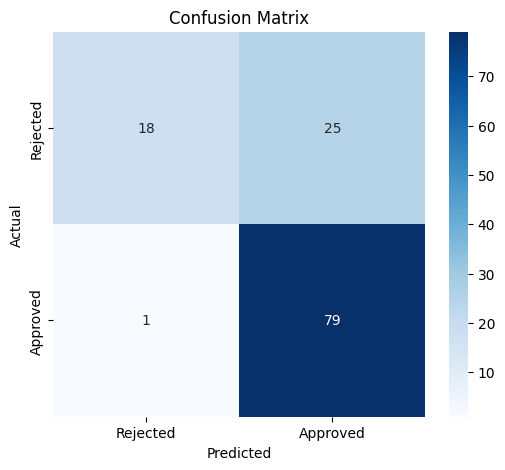


✅ Model saved as loan_model.pkl!


In [30]:
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

# Evaluate
y_pred = best_model.predict(X_test)

print("✅ Accuracy:", round(accuracy_score(y_test, y_pred) * 100, 2), "%")
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

# Confusion Matrix graph
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Rejected', 'Approved'],
            yticklabels=['Rejected', 'Approved'])
plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.savefig('confusion_matrix.png')
plt.show()

# Model Save
joblib.dump(best_model, "loan_model.pkl")
print("\n✅ Model saved as loan_model.pkl!")

In [31]:
def predict_loan_status(input_data: dict):
    input_df = pd.DataFrame([input_data])
    prediction = best_model.predict(input_df)[0]
    probability = best_model.predict_proba(input_df).max()
    status = "✅ APPROVED" if prediction == 1 else "❌ REJECTED"
    print(f"Loan Status: {status}")
    print(f"Confidence: {round(probability*100, 2)}%")
    return prediction, probability

# Test!
sample = {
    "Gender": "Male",
    "Married": "Yes",
    "Dependents": "0",
    "Education": "Graduate",
    "Self_Employed": "No",
    "ApplicantIncome": 5000,
    "CoapplicantIncome": 2000,
    "LoanAmount": 150,
    "Loan_Amount_Term": 360,
    "Credit_History": 1,
    "Property_Area": "Urban"
}

predict_loan_status(sample)

Loan Status: ✅ APPROVED
Confidence: 88.59%


(np.int64(1), np.float64(0.8858978478049013))